# NIPS4B 2013 Bird Challenge — EDA

Multi-label audio: **87 classes** (species × call/song), **687 train + 1000
test** clips. Provided features are variable-length **MFCC cepstra**
(17 coeffs × N frames); we summarize each file into fixed per-coefficient stats
(`src/features.py`). Metric is **AUC pooled over all (file × class) pairs**, so
per-class prevalence and cross-class score comparability both matter.

This notebook answers: data distribution · target distribution · missing values ·
train/test distribution shift · feature correlation/redundancy · label-space
(co-occurrence) structure. Figures are saved to `reports/figures/`; written
conclusions live in `reports/EDA_FINDINGS.md`.

In [1]:
%matplotlib inline
import sys, pathlib
_root = pathlib.Path.cwd()
if not (_root / "src").exists():  # notebook runs from notebooks/
    _root = _root.parent
sys.path.insert(0, str(_root))

from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from scipy import stats
from src import data, features, cv

sns.set_theme(style="whitegrid")
FIG = data.ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

sp = data.load_species(); names = data.class_names()
file_ids, Y, dur = data.load_train_labels()
Xtr = features.feature_matrix("train"); Xte = features.feature_matrix("test")
fnames = features.feature_names()
nfr_tr, nfr_te = np.expm1(Xtr[:, -1]), np.expm1(Xte[:, -1])
print("classes", data.N_CLASSES, "| train", data.N_TRAIN, "| test", data.N_TEST)
print("feature matrix:", Xtr.shape, "(per-coeff mean/std/min/max/median + log n_frames)")

classes 87 | train 687 | test 1000
feature matrix: (687, 86) (per-coeff mean/std/min/max/median + log n_frames)


## 1. Data distribution
Clip durations and MFCC frame counts (a length/activity proxy), train vs test.

duration s: min=1.02 median=5.00 max=5.00
frames/file median — train 1288, test 1288


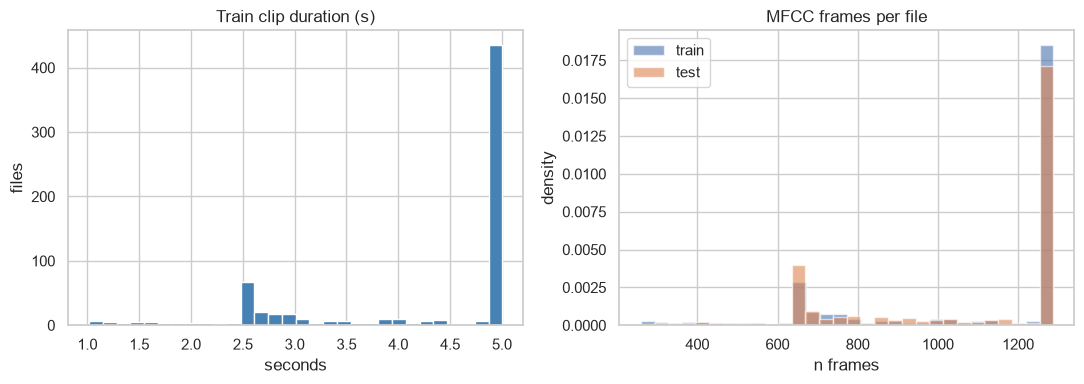

In [2]:
print(f"duration s: min={dur.min():.2f} median={np.median(dur):.2f} max={dur.max():.2f}")
print(f"frames/file median — train {np.median(nfr_tr):.0f}, test {np.median(nfr_te):.0f}")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(dur, bins=30, color="steelblue"); ax[0].set(title="Train clip duration (s)", xlabel="seconds", ylabel="files")
ax[1].hist(nfr_tr, bins=30, alpha=0.6, label="train", density=True)
ax[1].hist(nfr_te, bins=30, alpha=0.6, label="test", density=True)
ax[1].set(title="MFCC frames per file", xlabel="n frames", ylabel="density"); ax[1].legend()
fig.tight_layout(); fig.savefig(FIG / "duration_frames.png", dpi=110); plt.show()

## 2. Target distribution
Per-class prevalence (imbalance), classes-per-clip (label cardinality), empty clips, taxon/vocalization mix.

classes/clip: mean=1.71 max=6 | empty clips=100 (14.6%)
prevalence: min=7 (Colpal_song) median=13 max=20 (Erirub_song) | classes never present=0


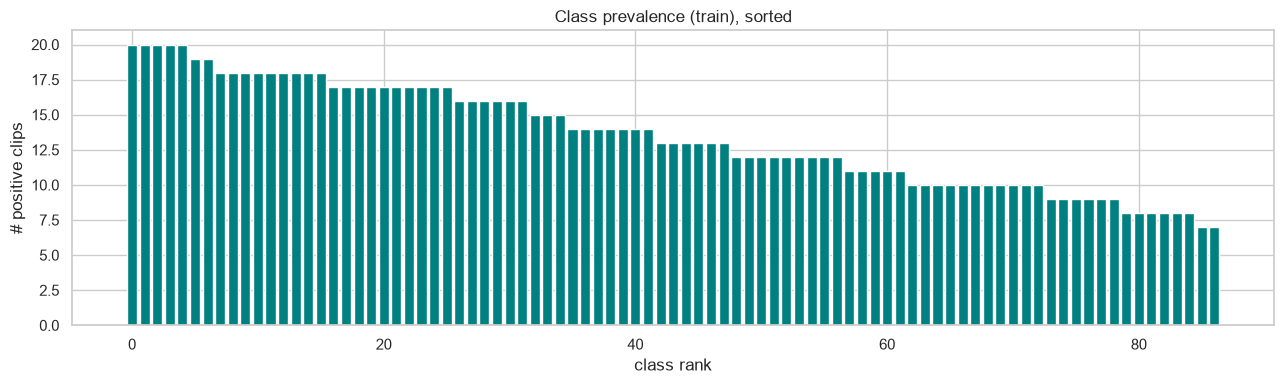

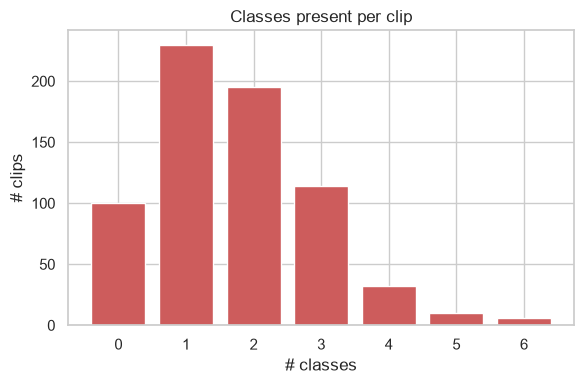

taxon: {'bird': 77, 'insect': 9, 'amphibian': 1}
vocalization: {'song': 45, 'call': 41, 'drum': 1}


In [3]:
prev = Y.sum(0); card = Y.sum(1)
print(f"classes/clip: mean={card.mean():.2f} max={card.max()} | empty clips={int((card==0).sum())} ({(card==0).mean()*100:.1f}%)")
print(f"prevalence: min={prev.min()} ({names[prev.argmin()]}) median={int(np.median(prev))} max={prev.max()} ({names[prev.argmax()]}) | classes never present={(prev==0).sum()}")

order = np.argsort(prev)[::-1]
fig, ax = plt.subplots(figsize=(13, 4)); ax.bar(range(len(prev)), prev[order], color="teal")
ax.set(title="Class prevalence (train), sorted", xlabel="class rank", ylabel="# positive clips")
fig.tight_layout(); fig.savefig(FIG / "class_prevalence.png", dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(6, 4)); v, c = np.unique(card, return_counts=True)
ax.bar(v, c, color="indianred"); ax.set(title="Classes present per clip", xlabel="# classes", ylabel="# clips")
fig.tight_layout(); fig.savefig(FIG / "label_cardinality.png", dpi=110); plt.show()

sp2 = sp.copy(); sp2["voc"] = sp2["class name"].str.rsplit("_", n=1).str[-1]
print("taxon:", sp2["type"].value_counts().to_dict())
print("vocalization:", sp2["voc"].value_counts().to_dict())

## 3. Missing values
Aggregated features must be finite. A few cepstra files contain `-inf`/`nan` (silent frames); `features.mfcc_stats` masks these with nan-aware reductions.

In [4]:
print("non-finite in train features:", int((~np.isfinite(Xtr)).sum()), "| test:", int((~np.isfinite(Xte)).sum()))
raw_nonfinite = sum(int((~np.isfinite(data.load_mfcc(data.train_mfcc_path(i)))).any()) for i in range(1, data.N_TRAIN+1))
print("train MFCC files containing any non-finite raw value:", raw_nonfinite, "(handled by mfcc_stats)")
print("classes never present:", int((Y.sum(0)==0).sum()))

non-finite in train features: 0 | test: 0


train MFCC files containing any non-finite raw value: 1 (handled by mfcc_stats)
classes never present: 0


## 4. Train vs test distribution shift
Test labels are hidden, so we compare **feature** distributions. Per-feature
two-sample KS test (train vs test) — many significant shifts would mean CV AUC
may be optimistic relative to the leaderboard.

features with KS p<0.01: 36/86 | p<0.05: 55/86
most-shifted features: ['mfcc7_std', 'mfcc6_std', 'mfcc9_std', 'mfcc16_std', 'mfcc7_min']


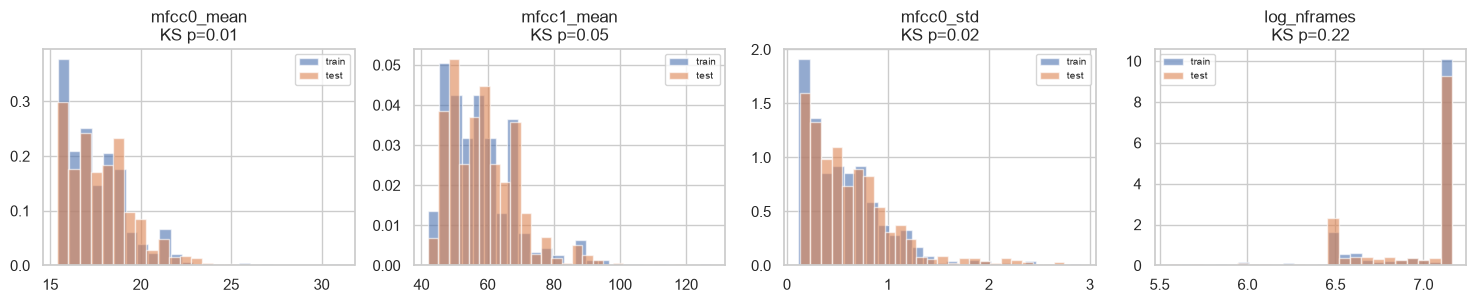

In [5]:
ks_p = np.array([stats.ks_2samp(Xtr[:, j], Xte[:, j]).pvalue for j in range(Xtr.shape[1])])
print(f"features with KS p<0.01: {(ks_p<0.01).sum()}/{len(ks_p)} | p<0.05: {(ks_p<0.05).sum()}/{len(ks_p)}")
print("most-shifted features:", [fnames[i] for i in np.argsort(ks_p)[:5]])
show = [fnames.index(n) for n in ("mfcc0_mean","mfcc1_mean","mfcc0_std","log_nframes")]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for a, j in zip(axes, show):
    a.hist(Xtr[:, j], bins=25, alpha=0.6, label="train", density=True)
    a.hist(Xte[:, j], bins=25, alpha=0.6, label="test", density=True)
    a.set_title(f"{fnames[j]}\nKS p={ks_p[j]:.2f}"); a.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "train_test_shift.png", dpi=110); plt.show()

## 5. Feature correlation & redundancy
MFCC coefficient correlation, near-zero-variance check, and PCA scree (how many components capture the variance).

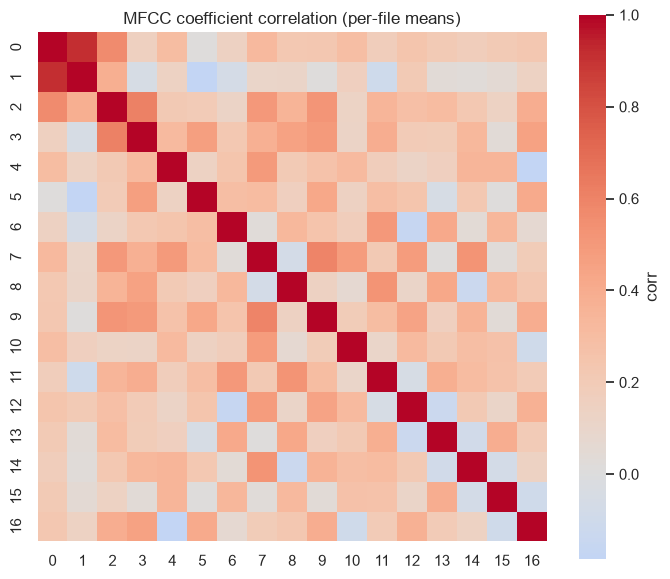

near-zero-variance features: 0
PCA components for 90% var: 20 | 95%: 31 (of 86)


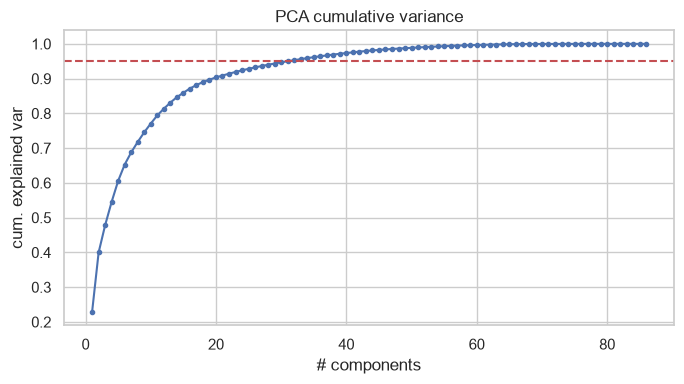

In [6]:
mean_cols = [fnames.index(f"mfcc{c}_mean") for c in range(data.N_MFCC)]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(np.corrcoef(Xtr[:, mean_cols].T), cmap="coolwarm", center=0, square=True, ax=ax, cbar_kws={"label":"corr"})
ax.set(title="MFCC coefficient correlation (per-file means)")
fig.tight_layout(); fig.savefig(FIG / "mfcc_coeff_correlation.png", dpi=110); plt.show()

print("near-zero-variance features:", int((Xtr.var(0) < 1e-8).sum()))
Z = (Xtr - Xtr.mean(0)) / (Xtr.std(0) + 1e-9)
ev = np.linalg.svd(Z, full_matrices=False)[1]**2; cum = np.cumsum(ev/ev.sum())
print(f"PCA components for 90% var: {np.searchsorted(cum,0.90)+1} | 95%: {np.searchsorted(cum,0.95)+1} (of {Xtr.shape[1]})")
fig, ax = plt.subplots(figsize=(7, 4)); ax.plot(range(1,len(cum)+1), cum, marker="o", ms=3)
ax.axhline(0.95, ls="--", c="r"); ax.set(title="PCA cumulative variance", xlabel="# components", ylabel="cum. explained var")
fig.tight_layout(); fig.savefig(FIG / "pca_scree.png", dpi=110); plt.show()

## 6. Label space & co-occurrence
**High-cardinality categoricals: N/A** (no categorical features — inputs are
numeric MFCC). The multi-label analogue is the 87-dim label space: which classes
co-occur. `C = Yᵀ·Y` gives pairwise co-occurrence; strong pairs suggest label
correlations a chain/joint model could exploit.

top co-occurring class pairs:
  ('Erirub_call', 'Prumod_song', 10)
  ('Petpet_call', 'Sylcan_song', 10)
  ('Lyrple_song', 'Plaaff_song', 9)
  ('Galcri_call', 'Plasab_song', 9)
  ('Petpet_song', 'Sylcan_song', 9)
  ('Cisjun_song', 'Tibtom_song', 9)
  ('Parate_song', 'Siteur_song', 8)
  ('Chlchl_call', 'Pasdom_call', 8)


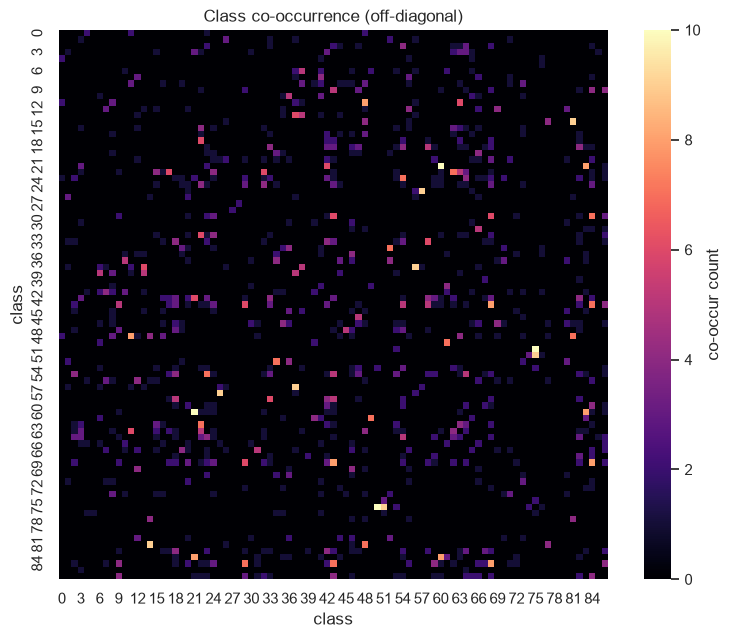

multilabel-stratified folds keep per-fold prevalence consistent; max rel. std across folds = 0.50 (rare classes vary most)


In [7]:
C = Y.T @ Y; off = C.copy(); np.fill_diagonal(off, 0)
pairs = []
for i, j in zip(*np.unravel_index(np.argsort(off, axis=None)[::-1], off.shape)):
    if i < j: pairs.append((names[i], names[j], int(off[i, j])));
    if len(pairs) >= 8: break
print("top co-occurring class pairs:"); [print(" ", p) for p in pairs]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(off, cmap="magma", square=True, ax=ax, cbar_kws={"label":"co-occur count"})
ax.set(title="Class co-occurrence (off-diagonal)", xlabel="class", ylabel="class")
fig.tight_layout(); fig.savefig(FIG / "class_cooccurrence.png", dpi=110); plt.show()

folds = cv.make_folds(Y)
fp = np.array([Y[va].mean(0) for _, va in folds])
print("multilabel-stratified folds keep per-fold prevalence consistent; "
      f"max rel. std across folds = {fp.std(0).max()/(fp.mean(0).mean()+1e-9):.2f} (rare classes vary most)")

## Summary
Key numbers and modeling implications are written up in **`reports/EDA_FINDINGS.md`**.